In [1]:
import os
os.chdir('../../..')

In [33]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import re

from rdkit import Chem
from rdkit.Chem import Draw
from collections import Counter
from scipy.stats import ks_2samp
from torch_geometric.datasets import QM9
from rdkit.Chem import Descriptors, rdMolDescriptors
from tqdm import tqdm

from src.datasets import QM9Dataset

In [3]:
qm9 = QM9(root="data/QM9")

In [34]:

SMILES_TOKEN_REGEX = r"(\[[^\]]+\]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|<|\*|\$|\%[0-9]{2}|[0-9])"

data_rows = []

for data in tqdm(qm9, desc="Processing QM9 into Polars"):
    smiles = data.smiles if isinstance(data.smiles, str) else data.smiles[0]
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        continue  
        
    y = data.y.view(-1)
    
    # 3. Extract properties natively found in PyG's QM9 targets 
    mu = y[0].item()
    alpha = y[1].item()
    gap = y[4].item()
    cv = y[11].item()
    
    # 4. Calculate Chemoinformatics properties using RDKit
    mol_weight = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    num_heavy_atoms = mol.GetNumHeavyAtoms()
    fraction_csp3 = rdMolDescriptors.CalcFractionCSP3(mol)
    
    # 5. Native PyG total atom count
    num_atoms = data.num_nodes 
    
    # 6. Structure Classification Logic
    if any(atom.GetIsAromatic() for atom in mol.GetAtoms()):
        structure_class = "Aromatic"
    elif mol.GetRingInfo().NumRings() > 0:
        structure_class = "Cyclic"
    else:
        structure_class = "Acyclic"
        
    # 7. Heavy Atom Proportion (hap)
    hap = num_heavy_atoms / num_atoms if num_atoms > 0 else 0

    # 8. Average Bond Length (using PyG 3D coordinates)
    if data.edge_index is not None and data.edge_index.size(1) > 0:
        row, col = data.edge_index
        # Calculate Euclidean distance between all bonded atom pairs
        distances = torch.norm(data.pos[row] - data.pos[col], dim=1)
        avg_bond_length = distances.mean().item()
    else:
        # Fallback for single-atom molecules (like isolated Methane carbon without H edges, though rare in QM9)
        avg_bond_length = 0.0

    raw_token_count = len(re.findall(SMILES_TOKEN_REGEX, smiles))

    # Append to our list of records
    data_rows.append({
        "canonical_smiles": smiles,
        "structure_class": structure_class,
        "mol_weight": mol_weight,
        "alpha": alpha,
        "hap": hap,
        "logp": logp,
        "tpsa": tpsa,
        "num_atoms": num_atoms,                 
        "num_heavy_atoms": num_heavy_atoms,
        "avg_bond_length": avg_bond_length,
        "fraction_csp3": fraction_csp3,
        "mu": mu,
        "gap": gap,
        "cv": cv,
        "raw_token_count": raw_token_count
    })

# Convert directly to a Polars DataFrame
df = pl.DataFrame(data_rows)

print(df.head())

Processing QM9 into Polars:   0%|          | 207/130831 [00:00<01:03, 2067.89it/s][20:13:23] Explicit valence for atom # 1 C, 5, is greater than permitted
[20:13:23] Explicit valence for atom # 2 C, 5, is greater than permitted
[20:13:23] Explicit valence for atom # 2 C, 5, is greater than permitted
[20:13:23] Explicit valence for atom # 2 C, 5, is greater than permitted
[20:13:23] Explicit valence for atom # 2 C, 5, is greater than permitted
Processing QM9 into Polars:   1%|▏         | 1720/130831 [00:00<00:31, 4161.13it/s][20:13:23] Explicit valence for atom # 2 C, 5, is greater than permitted
[20:13:23] Explicit valence for atom # 2 C, 5, is greater than permitted
[20:13:23] Explicit valence for atom # 1 C, 5, is greater than permitted
[20:13:23] Explicit valence for atom # 2 C, 5, is greater than permitted
[20:13:23] Explicit valence for atom # 2 C, 5, is greater than permitted
[20:13:23] Explicit valence for atom # 2 C, 5, is greater than permitted
[20:13:23] Explicit valence for 

shape: (5, 15)
┌─────────────┬─────────────┬────────────┬───────────┬───┬────────┬───────────┬───────┬────────────┐
│ canonical_s ┆ structure_c ┆ mol_weight ┆ alpha     ┆ … ┆ mu     ┆ gap       ┆ cv    ┆ raw_token_ │
│ miles       ┆ lass        ┆ ---        ┆ ---       ┆   ┆ ---    ┆ ---       ┆ ---   ┆ count      │
│ ---         ┆ ---         ┆ f64        ┆ f64       ┆   ┆ f64    ┆ f64       ┆ f64   ┆ ---        │
│ str         ┆ str         ┆            ┆           ┆   ┆        ┆           ┆       ┆ i64        │
╞═════════════╪═════════════╪════════════╪═══════════╪═══╪════════╪═══════════╪═══════╪════════════╡
│ [H]C([H])([ ┆ Acyclic     ┆ 16.043     ┆ 13.21     ┆ … ┆ 0.0    ┆ 13.736308 ┆ 6.469 ┆ 9          │
│ H])[H]      ┆             ┆            ┆           ┆   ┆        ┆           ┆       ┆            │
│ [H]N([H])[H ┆ Acyclic     ┆ 17.031     ┆ 9.46      ┆ … ┆ 1.6256 ┆ 9.249149  ┆ 6.316 ┆ 6          │
│ ]           ┆             ┆            ┆           ┆   ┆        ┆         

In [ ]:
#frames = qm9.get_positions()

2026-03-18 08:32:53.423 | SUCCESS  | src.datasets:get_positions:885 - Saved 2000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 2000).


In [35]:
df.filter(pl.col("canonical_smiles").is_duplicated())

canonical_smiles,structure_class,mol_weight,alpha,hap,logp,tpsa,num_atoms,num_heavy_atoms,avg_bond_length,fraction_csp3,mu,gap,cv,raw_token_count
str,str,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,i64
"""[H]N([H])/C(C(=O)[O-])=[N+](/[…","""Acyclic""",102.093,52.779999,0.538462,-4.1961,80.12,13,7,1.205007,0.333333,8.8749,5.366085,25.863001,29
"""[H]N([H])/C(C(=O)[O-])=[N+](/[…","""Acyclic""",102.093,52.77,0.538462,-4.1961,80.12,13,7,1.204956,0.333333,8.8758,5.363364,25.860001,29
"""[H]C1=C([H])N([H])C(N([H])[H])…","""Aromatic""",110.116,68.160004,0.571429,-0.0429,58.88,14,8,1.235497,0.0,6.9905,5.523911,26.525,29
"""[H]C1=C([H])N([H])C(N([H])[H])…","""Aromatic""",110.116,68.160004,0.571429,-0.0429,58.88,14,8,1.235504,0.0,6.9905,5.523911,26.525,29
"""[H]C1=C(C#N)OC(N([H])[H])=C1[H…","""Aromatic""",108.1,68.559998,0.666667,0.73348,62.95,12,8,1.250449,0.0,6.249,5.01778,25.18,23
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""[H]OC1=C([H])N=NC(N([H])[H])=C…","""Aromatic""",129.094,64.970001,0.692308,-0.0965,72.03,13,9,1.254586,0.0,4.1485,5.491258,28.558001,24
"""[H]OC1=C(N([H])[H])C(F)=C([H])…","""Aromatic""",129.094,64.93,0.692308,-0.0965,72.03,13,9,1.253848,0.0,3.6518,5.518469,28.334999,26
"""[H]OC1=C(N([H])[H])C(F)=C([H])…","""Aromatic""",129.094,64.93,0.692308,-0.0965,72.03,13,9,1.253842,0.0,3.6514,5.518469,28.334,26


In [36]:
mid = df.height // 2
df.slice(mid, 5)

canonical_smiles,structure_class,mol_weight,alpha,hap,logp,tpsa,num_atoms,num_heavy_atoms,avg_bond_length,fraction_csp3,mu,gap,cv,raw_token_count
str,str,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,i64
"""[H][C-]1C(=O)N2[C@]3([H])C([H]…","""Cyclic""",122.147,77.269997,0.5625,0.19369,20.08,16,9,1.322333,0.714286,4.5989,4.073545,28.826,35
"""[H][C-]1C(=O)[C@]2([H])[N@@H+]…","""Cyclic""",123.155,78.230003,0.5625,-1.57101,21.51,16,9,1.324632,0.714286,3.4626,4.204159,28.702999,35
"""[H][C-]1C(=O)[C@]2([H])[C@]3([…","""Cyclic""",122.147,77.860001,0.5625,-0.25011,29.1,16,9,1.322159,0.714286,4.6299,4.168784,28.812,35
"""[H]O[C@@]12[C@H]3[C-]([H])C(=O…","""Cyclic""",123.131,74.269997,0.6,-0.22961,37.3,15,9,1.329953,0.714286,2.8433,4.223207,28.052999,32
"""[H]O[C@@]12[C@H]3[C-]([H])C(=O…","""Cyclic""",124.119,70.599998,0.642857,-1.52531,49.33,14,9,1.335154,0.666667,3.1897,4.095314,27.698,29


# Visualization of a few molecules
- Ensuring that SMILES works for generating unique identifiers for each molecule

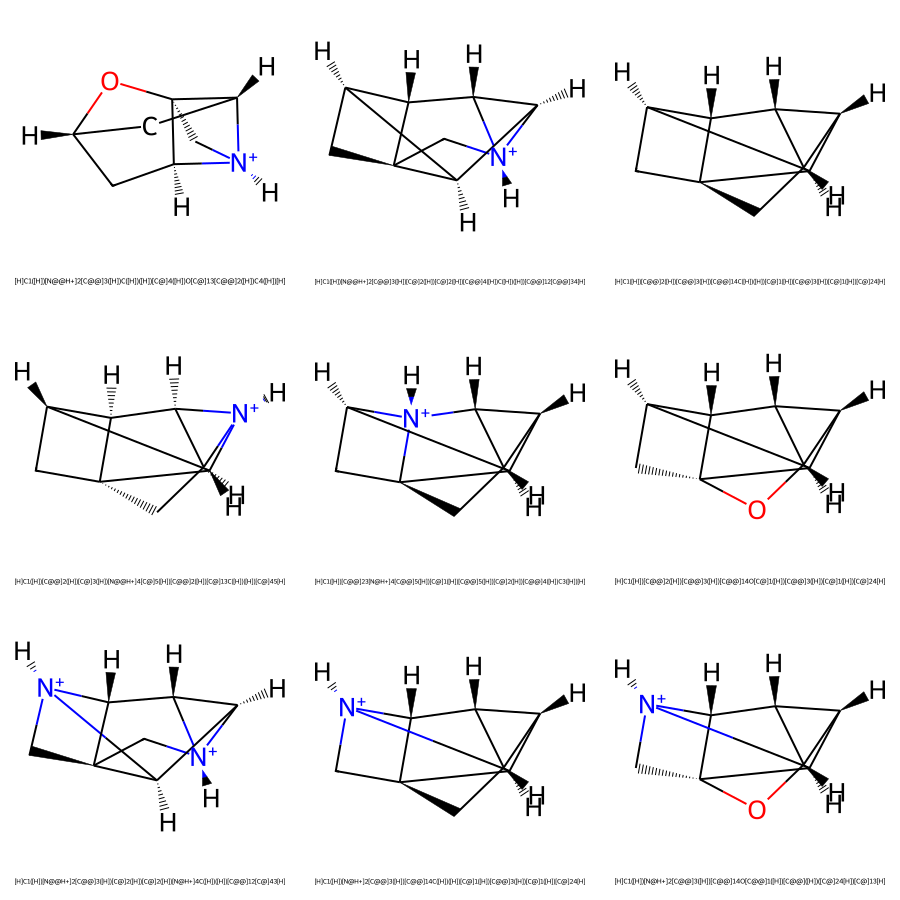

In [18]:
sample_smiles = df.tail(9)["canonical_smiles"].to_list()
mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
img

# Figures for report

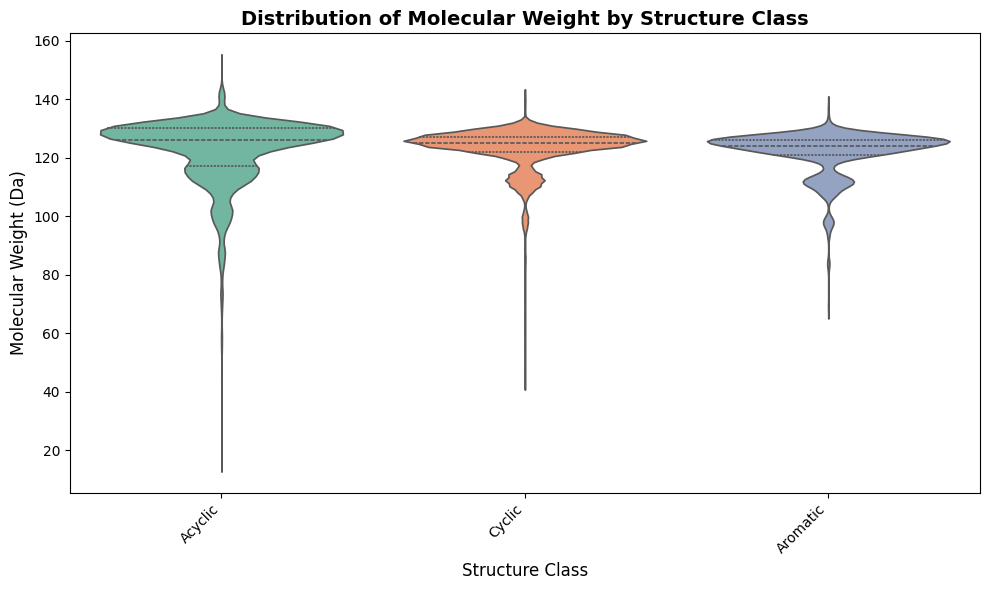

In [19]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df, 
    x='structure_class', 
    y='mol_weight', 
    palette='Set2', 
    hue='structure_class',
    inner='quartile'
)
plt.title('Distribution of Molecular Weight by Structure Class', fontsize=14, fontweight='bold')
plt.xlabel('Structure Class', fontsize=12)
plt.ylabel('Molecular Weight (Da)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/qm9/analysis/distribution_by_structure_class.png', dpi=300)
plt.show()

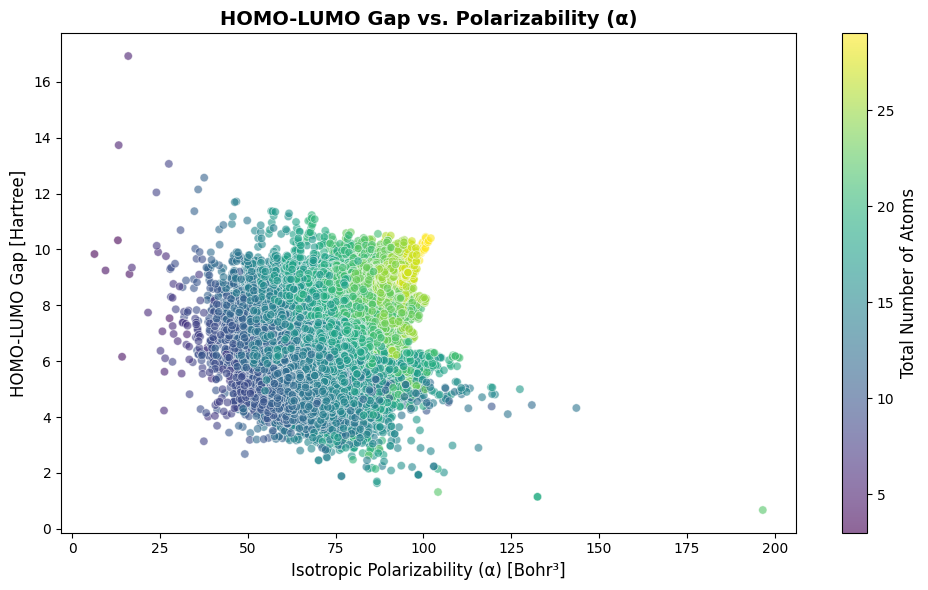

In [20]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['alpha'], 
    df['gap'], 
    c=df['num_atoms'], 
    cmap='viridis', 
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)
cbar = plt.colorbar(scatter)
cbar.set_label('Total Number of Atoms', fontsize=12)

plt.title('HOMO-LUMO Gap vs. Polarizability (α)', fontsize=14, fontweight='bold')
plt.xlabel('Isotropic Polarizability (α) [Bohr³]', fontsize=12)
plt.ylabel('HOMO-LUMO Gap [Hartree]', fontsize=12)
plt.tight_layout()
plt.show()

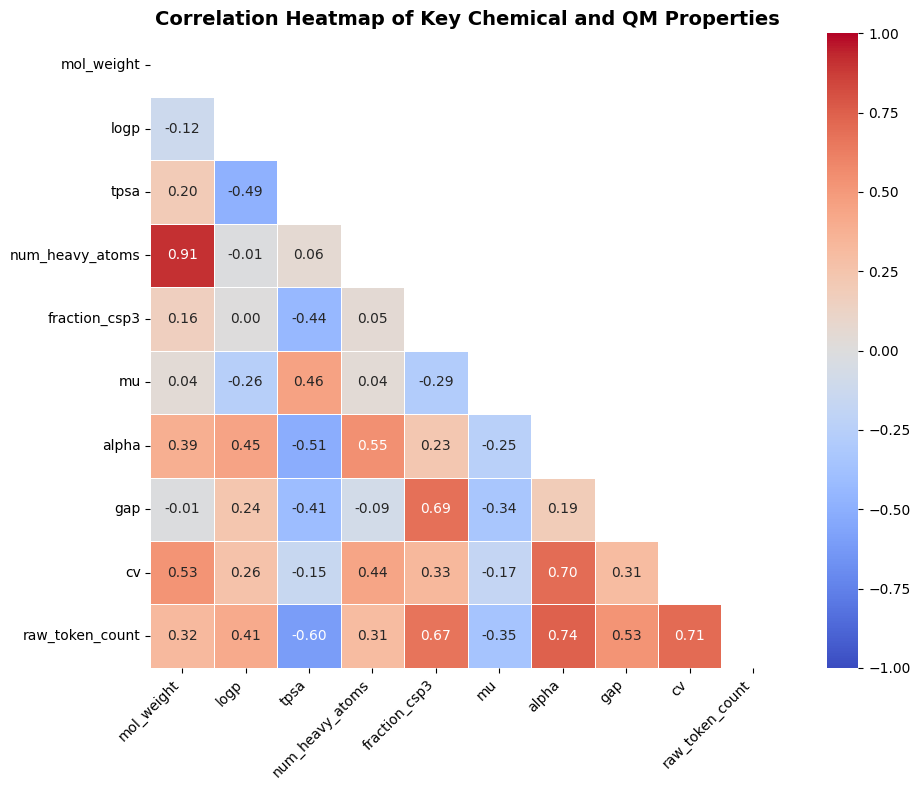

In [22]:
plt.figure(figsize=(10, 8))

# Select a mix of 2D cheminformatics features and 3D quantum features
features_of_interest = [
    'mol_weight', 'logp', 'tpsa', 'num_heavy_atoms', 
    'fraction_csp3', 'mu', 'alpha', 'gap', 'cv', 'raw_token_count'
]

# Calculate Spearman correlation (better for potentially non-linear chemical features)
corr = df[features_of_interest].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True,
    xticklabels=features_of_interest,   # ← use names instead of 0,1,2…
    yticklabels=features_of_interest
)

plt.xticks(rotation=45, ha='right')      # if you want them tilted
plt.title('Correlation Heatmap of Key Chemical and QM Properties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
df['structure_class']

structure_class
str
"""Acyclic"""
"""Acyclic"""
"""Acyclic"""
"""Acyclic"""
"""Acyclic"""
…
"""Cyclic"""
"""Cyclic"""
"""Cyclic"""


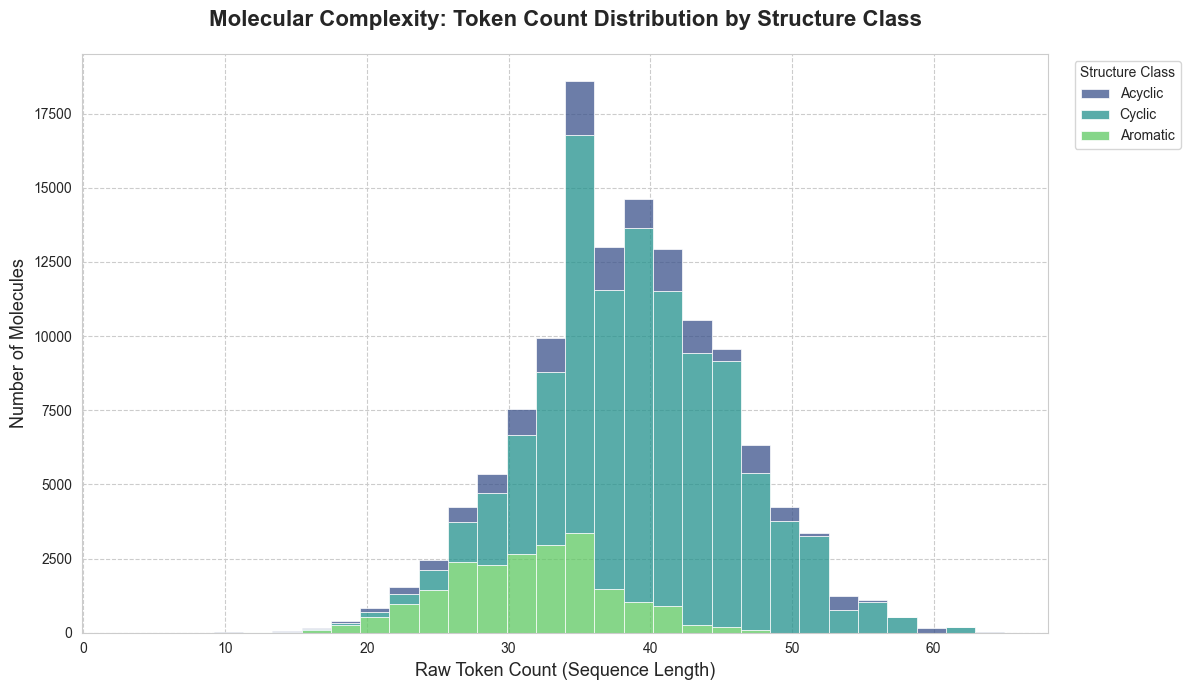

In [37]:
plt.figure(figsize=(12, 7))

# 1. Create the plot (Seaborn creates the legend automatically here)
ax = sns.histplot(
    data=df,
    x='raw_token_count',
    hue='structure_class',
    multiple='stack',
    palette='viridis',
    edgecolor='white',
    linewidth=0.5,
    bins=30
)

# 2. Access the auto-generated legend and move it
# This avoids the "No artists with labels found" warning
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title='Structure Class')

plt.title('Molecular Complexity: Token Count Distribution by Structure Class', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Raw Token Count (Sequence Length)', fontsize=13)
plt.ylabel('Number of Molecules', fontsize=13)

plt.tight_layout()
plt.savefig('figures/qm9/analysis/plot_token_count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

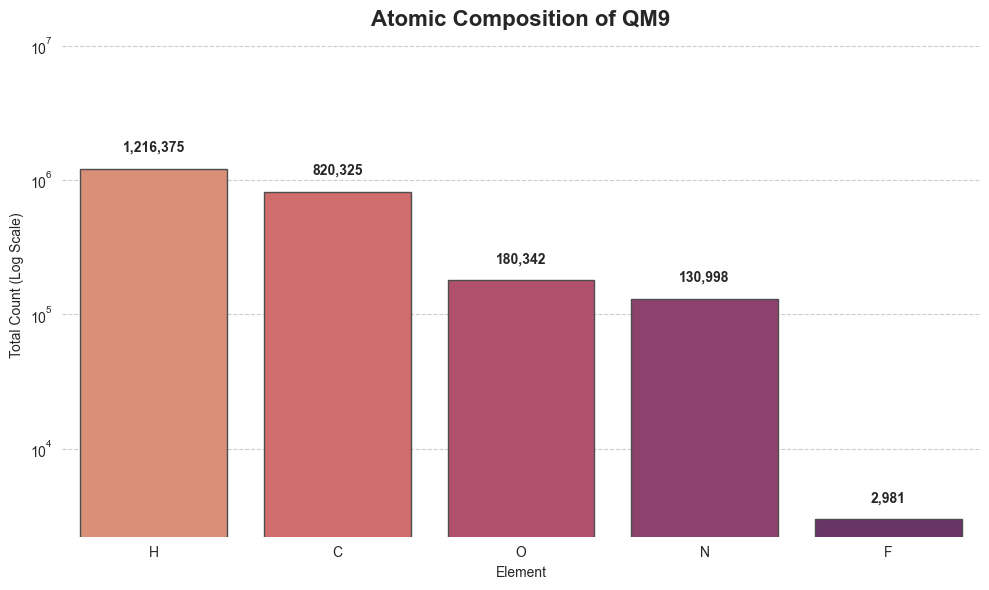

In [38]:
# 1. Processing - Using map(str) to avoid the AttributeError
all_smiles = "".join(map(str, df["canonical_smiles"]))

# Regex: Find Capital letters followed by optional lowercase (Elements)
# We filter out common SMILES syntax that isn't an element
tokens = re.findall(r'[A-Z][a-z]?', all_smiles)
valid_elements = {'H', 'C', 'N', 'O', 'F', 'S', 'Cl', 'P', 'Br', 'I'}
atom_counts = Counter([t for t in tokens if t in valid_elements])

comp_df = pd.DataFrame(atom_counts.items(), columns=['Element', 'Count'])
comp_df = comp_df.sort_values('Count', ascending=False)

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid", {'axes.grid' : True, 'grid.linestyle': '--'})

ax = sns.barplot(
    data=comp_df, 
    x='Element', 
    y='Count', 
    palette='flare',
    hue='Element',
    edgecolor='0.3'
)

ax.set_yscale("log")
plt.ylim(top=comp_df['Count'].max() * 10) # Added more headroom for labels

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.title('Atomic Composition of QM9', fontsize=16, fontweight='bold')
plt.ylabel('Total Count (Log Scale)')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('figures/qm9/analysis/atomic_composition.png', dpi=300, bbox_inches='tight')
plt.show()

# Average weight of molecule
- Also average bond length

In [39]:
mol_weights = df['mol_weight']
print(np.average(mol_weights))

123.00952836170278


In [40]:
mol_bond_lengths = df['avg_bond_length']
plotting = mol_bond_lengths.hist()
plotting

breakpoint,category,count
f64,cat,u32
1.005475,"""[0.962108, 1.005475]""",1
1.048843,"""(1.005475, 1.048843]""",1
1.09221,"""(1.048843, 1.09221]""",1
1.135578,"""(1.09221, 1.135578]""",3
1.178945,"""(1.135578, 1.178945]""",11
1.222312,"""(1.178945, 1.222312]""",3695
1.26568,"""(1.222312, 1.26568]""",58452
1.309047,"""(1.26568, 1.309047]""",55142
1.352414,"""(1.309047, 1.352414]""",11292


# Similar Molecules for Grassmann stress test

In [ ]:
# from rdkit import Chem
# from rdkit.Chem import Draw
# import pandas as pd

# df = df.to_pandas()
# # Assuming your dataframe is named 'df'
# mol_ids = ["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]

# # FIX: Use boolean indexing instead of .filter()
# sample_smiles = df[df["mol_id"].isin(mol_ids)]["canonical_smiles"].tolist()

# # Generate molecules
# mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

# # Create the grid image
# img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
# img

KeyError: 'mol_id'

# Statified sampling

In [45]:
qm9_head = QM9Dataset(sampling_strategy="head", subset_size=2000)
df_first = qm9_head.load(force_process=True)


2026-03-27 20:14:55.661 | INFO     | src.datasets:_process_raw_qm9:414 - Processing raw QM9 data (Limit: 2000)...
2026-03-27 20:15:10.301 | INFO     | src.features:compute_soap:160 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-27 20:15:23.158 | SUCCESS  | src.datasets:add_soap:617 - Added SOAP embeddings.
2026-03-27 20:15:23.159 | INFO     | src.features:compute_acsf:190 - Computing ACSF (rcut=6.0)...
2026-03-27 20:15:33.334 | SUCCESS  | src.datasets:add_acsf:628 - Added ACSF embeddings.
2026-03-27 20:15:33.335 | INFO     | src.features:compute_coulomb_matrix:224 - Computing Coulomb matrices (n_atoms_max=None, permutation=sorted_l2)...
2026-03-27 20:15:42.308 | SUCCESS  | src.datasets:add_coulomb_matrix:645 - Added Coulomb matrix descriptors.
2026-03-27 20:15:42.317 | WARNING  | src.datasets:_process_raw_qm9:472 - Invalid molecules (SOAP+ACSF+Coulomb failure): ['qm9_700']
2026-03-27 20:15:42.324 | INFO     | src.datasets:_process_raw_qm9:478 - Valid molecules (SOAP+ACSF+Coulom

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-03-27 20:16:15.040 | INFO     | src.features:compute_selfies_onehot:132 - Computing One-Hot Encodings...
2026-03-27 20:16:17.515 | INFO     | src.features:compute_chemprop_embeddings:273 - Computing Chemprop embeddings on mps...
2026-03-27 20:16:17.515 | WARNING  | src.features:compute_chemprop_embeddings:281 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-03-27 20:16:20.331 | SUCCESS  | src.datasets:add_all_descriptors:703 - Finished adding all requested descriptors.
2026-03-27 20:16:20.891 | SUCCESS  | src.datasets:_process_raw_qm9:543 - Saved processed dataset with 2000 rows to data/QM9/dataset_cleaned.parquet


In [5]:
qm9_strat = QM9Dataset(sampling_strategy="stratified", stratify_by=['num_atoms', 'gap'], subset_size=2000)
df_strat = qm9_strat.load(force_process=True)

2026-03-27 09:53:09.278 | INFO     | src.datasets:_process_raw_qm9:414 - Processing raw QM9 data (Limit: 2000)...
2026-03-27 09:53:16.936 | INFO     | src.datasets:_process_raw_qm9:438 - Stratified sampling enabled. Selected 2201 indices from QM9.
2026-03-27 09:53:58.707 | INFO     | src.features:compute_soap:160 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-27 09:54:12.429 | SUCCESS  | src.datasets:add_soap:617 - Added SOAP embeddings.
2026-03-27 09:54:12.429 | INFO     | src.features:compute_acsf:190 - Computing ACSF (rcut=6.0)...
2026-03-27 09:54:25.236 | SUCCESS  | src.datasets:add_acsf:628 - Added ACSF embeddings.
2026-03-27 09:54:25.236 | INFO     | src.features:compute_coulomb_matrix:224 - Computing Coulomb matrices (n_atoms_max=None, permutation=sorted_l2)...
2026-03-27 09:54:37.179 | SUCCESS  | src.datasets:add_coulomb_matrix:645 - Added Coulomb matrix descriptors.
2026-03-27 09:54:37.180 | WARNING  | src.datasets:_process_raw_qm9:472 - Invalid molecules (SOAP+ACSF+Co

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-03-27 09:54:58.119 | INFO     | src.features:compute_selfies_onehot:132 - Computing One-Hot Encodings...
2026-03-27 09:54:58.625 | INFO     | src.features:compute_chemprop_embeddings:273 - Computing Chemprop embeddings on mps...
2026-03-27 09:54:58.626 | WARNING  | src.features:compute_chemprop_embeddings:281 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-03-27 09:55:00.114 | SUCCESS  | src.datasets:add_all_descriptors:703 - Finished adding all requested descriptors.
2026-03-27 09:55:00.415 | SUCCESS  | src.datasets:_process_raw_qm9:543 - Saved processed dataset with 2000 rows to data/QM9/dataset_cleaned.parquet


Extracting full QM9 population targets for validation...

--- Stratified Sample vs. Population ---
KS Statistic: 0.0192 (Closer to 0 is better)
P-value:      0.4592 (Larger than 0.05 is good)

--- Head Sample vs. Population ---
KS Statistic: 0.1367
P-value:      0.0000


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_2177/2219421257.py:28: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(pop_gaps, label="Original QM9 Population", color="gray", shade=True, bw_adjust=0.5)


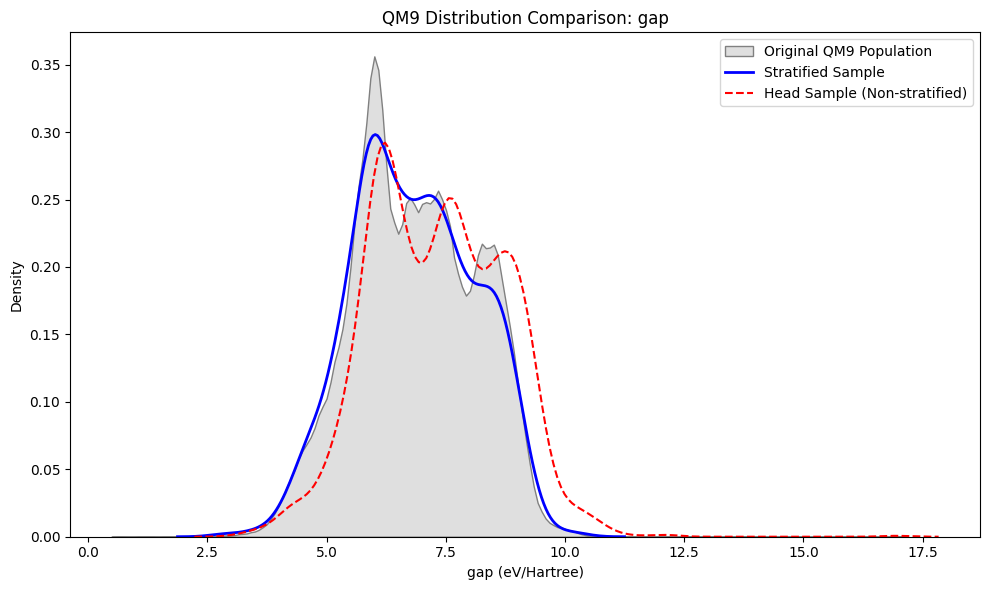

In [8]:

# 2. Lightning-fast Population Extraction (Bypasses SOAP/ACSF processing)
print("Extracting full QM9 population targets for validation...")
raw_dataset = QM9(root="data/QM9")
gap_idx = QM9Dataset.QM9_TARGETS.index("gap")

# Extract the gap values for all 130,000+ molecules directly
pop_gaps = np.array([data.y[0, gap_idx].item() for data in raw_dataset])

# 3. Clean nulls
strat_gaps = df_strat["gap"].drop_nulls().to_numpy()
head_gaps = df_first["gap"].drop_nulls().to_numpy()

# 4. Kolmogorov-Smirnov Tests
print("\n--- Stratified Sample vs. Population ---")
stat_strat, p_strat = ks_2samp(pop_gaps, strat_gaps)
print(f"KS Statistic: {stat_strat:.4f} (Closer to 0 is better)")
print(f"P-value:      {p_strat:.4f} (Larger than 0.05 is good)")

print("\n--- Head Sample vs. Population ---")
stat_head, p_head = ks_2samp(pop_gaps, head_gaps)
print(f"KS Statistic: {stat_head:.4f}")
print(f"P-value:      {p_head:.4f}")

# 5. Visual Validation
plt.figure(figsize=(10, 6))

# Plot Population
sns.kdeplot(pop_gaps, label="Original QM9 Population", color="gray", shade=True, bw_adjust=0.5)

# Plot Stratified
sns.kdeplot(strat_gaps, label="Stratified Sample", color="blue", linewidth=2)

# Plot Head Sample
sns.kdeplot(head_gaps, label="Head Sample (Non-stratified)", color="red", linestyle="--")

plt.title("QM9 Distribution Comparison: gap")
plt.xlabel("gap (eV/Hartree)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()

plt.savefig('figures/qm9/sampling/stat_sampling_validation.png', dpi=300)

plt.show()